Age Group Segment Summary:
           Number of Customers  Average Income  Average CLV      Total CLV
age_group                                                                 
18-25                       81    50634.018330   718.371170   58188.064760
26-35                       73    48747.148046   747.738562   54584.915035
36-50                      160    48516.895668   732.796612  117247.457917
51-70                      186    50713.163384   762.693498  141860.990683

Successfully identified 50 customers in the top 10% bracket.


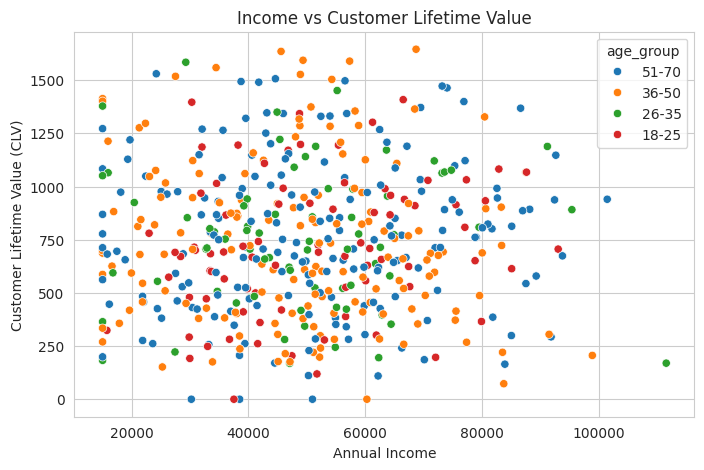

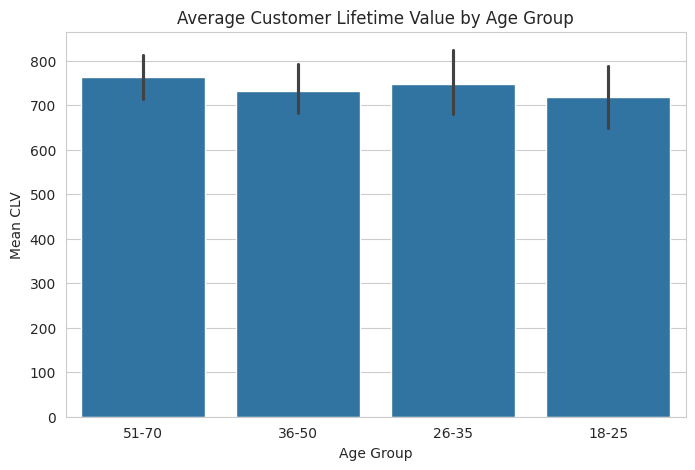

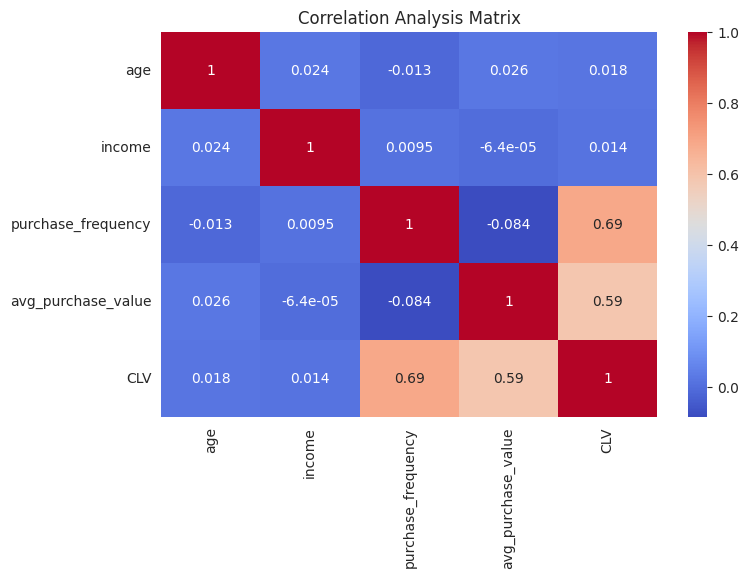

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting the global style
sns.set_style("whitegrid")

# Provided scenario dataset generation
np.random.seed(42)
n_customers = 500

ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})


# TODO: Calculate customer lifetime value (CLV)
#CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
#where churn_risk = 1 - (purchase_frequency / max_frequency)

# Finding max frequency to compute churn risk ratio
max_freq = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_freq)

# Calculating final customer lifetime value metric
customers['CLV'] = customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + customers['churn_risk'])


# TODO: Create age groups: 18-25, 26-35, 36-50, 51-70

# Building categorical bins using explicit boolean mask logic from Exercise 5
customers['age_group'] = '18-25'
customers.loc[(customers['age'] >= 26) & (customers['age'] <= 35), 'age_group'] = '26-35'
customers.loc[(customers['age'] >= 36) & (customers['age'] <= 50), 'age_group'] = '36-50'
customers.loc[(customers['age'] >= 51) & (customers['age'] <= 70), 'age_group'] = '51-70'


# TODO: For each age group, calculate:
# Number of customers
# Average income
# Average CLV
# Total CLV

# Aggregating specific metrics using separate groupby runs
group_counts = customers.groupby('age_group')['age'].count()
group_avg_income = customers.groupby('age_group')['income'].mean()
group_avg_clv = customers.groupby('age_group')['CLV'].mean()
group_total_clv = customers.groupby('age_group')['CLV'].sum()

# Combining summary columns using a classic dictionary structural layout
summary_dictionary = {
    'Number of Customers': group_counts,
    'Average Income': group_avg_income,
    'Average CLV': group_avg_clv,
    'Total CLV': group_total_clv
}
age_group_summary = pd.DataFrame(summary_dictionary)

print("Age Group Segment Summary:")
print(age_group_summary)


# TODO: Identify top 10% of customers by CLV

# Finding the row cutoff point for 10% of our 500 total rows
total_top_rows = int(len(customers) * 0.10)
customers_sorted = customers.sort_values('CLV', ascending=False)

# Extracting the boundary value to handle any tied scores flawlessly
clv_cutoff_score = customers_sorted['CLV'].head(total_top_rows).min()
top_10_percent_customers = customers[customers['CLV'] >= clv_cutoff_score]

print(f"\nSuccessfully identified {len(top_10_percent_customers)} customers in the top 10% bracket.")


# TODO: Create visualizations:
#        1. Scatter plot of income vs CLV (color by age group)
#        2. Bar chart of average CLV by age group
#        3. Correlation heatmap

# 1. Standalone scatter plot analyzing income vs metrics
plt.figure(figsize=(8, 5))
sns.scatterplot(data=customers, x='income', y='CLV', hue='age_group')
plt.title('Income vs Customer Lifetime Value')
plt.xlabel('Annual Income')
plt.ylabel('Customer Lifetime Value (CLV)')
plt.show()

# 2. Standalone bar chart evaluating group performance
plt.figure(figsize=(8, 5))
sns.barplot(data=customers, x='age_group', y='CLV')
plt.title('Average Customer Lifetime Value by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Mean CLV')
plt.show()

# 3. Correlation heatmap using the strict sequential layout from Section 4.3
numerical_columns = customers[['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'CLV']]
correlation = numerical_columns.corr()
plt.figure(figsize=(8, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Analysis Matrix')
plt.show()